# 02 - EDA Transacional do Dataset Unificado

## Objetivo

Realizar análise exploratória transacional sobre o dataset unificado do Instacart em nível `pedido-produto`.

Este notebook busca entender padrões de comportamento relacionados a usuários, pedidos, produtos, recompra, categorias e sazonalidade temporal. Os insights gerados aqui serão usados posteriormente para orientar a etapa de feature engineering e a construção do dataset de modelagem.

Este notebook cobre:

- Análise geral de volume de usuários, pedidos, produtos, aisles e departments.
- Distribuição de pedidos por usuário.
- Distribuição de itens por pedido.
- Análise de produtos, aisles e departments mais frequentes.
- Análise de recompra geral e por diferentes dimensões.
- Análise temporal por dia da semana, hora do dia e intervalo entre pedidos.
- Comparação exploratória entre os conjuntos `prior` e `train`.
- Consolidação de insights para etapas futuras de feature engineering, baseline e modelagem.

## Inputs

- `data/processed/orders_product_unified.parquet`

A amostra auxiliar abaixo pode ser usada somente para desenvolvimento rápido de visualizações e validação de código:

- `data/test_sample/orders_product_sample.parquet`

## Outputs esperados

- Estatísticas descritivas do dataset transacional unificado.
- Tabelas e visualizações exploratórias sobre usuários, pedidos, produtos, categorias, recompra e padrões temporais.
- Identificação de comportamentos relevantes para recomendação de produtos.
- Registro dos principais insights para orientar os próximos notebooks:
  - Feature engineering.
  - Construção do dataset de modelagem em nível `user_id-product_id`.
  - Definição de baselines.
  - Experimentos com modelos.

## Limites deste notebook

Este notebook é apenas uma análise exploratória transacional.

Ele não constrói o dataset final de modelagem em nível `user_id-product_id`.

Ele não define split final de treino e validação.

Ele não define estratégia final de candidatos.

Ele não treina modelos.

Ele não implementa baselines.

As conclusões analíticas devem ser feitas usando o dataset completo em `data/processed/orders_product_unified.parquet`.

A amostra em `data/test_sample/orders_product_sample.parquet` deve ser usada apenas para acelerar o desenvolvimento de código e visualizações, sem embasar conclusões finais.

---

## 1. Setup inicial

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Configuração de visualização
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.4f}".format)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [2]:
PROJECT_ROOT = Path("..").resolve()

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
TEST_SAMPLE_DIR = DATA_DIR / "test_sample"

UNIFIED_DATASET_PATH = PROCESSED_DIR / "orders_product_unified.parquet"
SAMPLE_DATASET_PATH = TEST_SAMPLE_DIR / "orders_product_sample.parquet"

assert UNIFIED_DATASET_PATH.exists(), (
    f"Dataset completo não encontrado em: {UNIFIED_DATASET_PATH}"
)

if not SAMPLE_DATASET_PATH.exists():
    print(f"Amostra auxiliar não encontrada em: {SAMPLE_DATASET_PATH}")

print("Arquivos encontrados com sucesso!")

Arquivos encontrados com sucesso!


### 1.1 Carregamento dos dados

In [3]:
USE_SAMPLE = False

dataset_path = SAMPLE_DATASET_PATH if USE_SAMPLE else UNIFIED_DATASET_PATH

df = pd.read_parquet(dataset_path)

print(f"Dataset carregado: {dataset_path}")
print(f"Shape: {df.shape[0]:,} linhas X {df.shape[1]:,} colunas")

if USE_SAMPLE:
    print(
        "⚠️​⚠️​ATENÇÃO: a amostra auxiliar está carregada.⚠️​⚠️​ "
        "⚠️​⚠️​Não use este resultado para conclusões analíticas finais.⚠️​⚠️​"
    )

Dataset carregado: C:\Users\erick\projetos\mlp-market-recommender-system\data\processed\orders_product_unified.parquet
Shape: 33,819,106 linhas X 15 colunas


---

## 2. Inspeções iniciais

**Objetivo**: Validar a estrutura do dataset antes da análise exploratória.

### 2.1 Visualização inicial

In [4]:
df.head()

,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,2,33120,1,1,202279,prior,3,5,9,8.0000,Organic Egg Whites,86,16,eggs,dairy eggs
1,2,28985,2,1,202279,prior,3,5,9,8.0000,Michigan Organic Kale,83,4,fresh vegetables,produce
2,2,9327,3,0,202279,prior,3,5,9,8.0000,Garlic Powder,104,13,spices seasonings,pantry
3,2,45918,4,1,202279,prior,3,5,9,8.0000,Coconut Butter,19,13,oils vinegars,pantry
4,2,30035,5,0,202279,prior,3,5,9,8.0000,Natural Sweetener,17,13,baking ingredients,pantry


In [5]:
df.sample(5, random_state=42)

,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
7009614,740068,21616,16,0,172941,prior,25,1,12,6.0000,Organic Baby Arugula,123,4,packaged vegetables fruits,produce
12886293,1360271,35503,5,1,5215,prior,3,3,13,20.0000,Organic Vanilla Almond Milk,91,16,soy lactosefree,dairy eggs
30444410,3211401,5819,13,1,113114,prior,33,6,11,4.0000,Baby Carrots,123,4,packaged vegetables fruits,produce
27795025,2931112,9387,3,0,138407,prior,1,1,20,NaN,Granny Smith Apples,24,4,fresh fruits,produce
10883987,1149035,8277,3,1,78836,prior,9,4,10,3.0000,Apple Honeycrisp Organic,24,4,fresh fruits,produce


### 2.2 Estrutura do dataset e estatísticas descritivas

In [6]:
df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33819106 entries, 0 to 33819105
Data columns (total 15 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   order_id                int64  
 1   product_id              int64  
 2   add_to_cart_order       int64  
 3   reordered               int64  
 4   user_id                 int64  
 5   eval_set                object 
 6   order_number            int64  
 7   order_dow               int64  
 8   order_hour_of_day       int64  
 9   days_since_prior_order  float64
 10  product_name            object 
 11  aisle_id                int64  
 12  department_id           int64  
 13  aisle                   object 
 14  department              object 
dtypes: float64(1), int64(10), object(4)
memory usage: 10.6 GB


In [7]:
df.describe(include=np.number)

,order_id,product_id,add_to_cart_order,reordered,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,aisle_id,department_id
count,"33,819,106.0000","33,819,106.0000","33,819,106.0000","33,819,106.0000","33,819,106.0000","33,819,106.0000","33,819,106.0000","33,819,106.0000","31,741,038.0000","33,819,106.0000","33,819,106.0000"
mean,"1,710,566.2909","25,575.5145",8.3677,0.5901,"102,944.4265",17.1400,2.7373,13.4312,11.3642,71.2180,9.9185
std,"987,400.7619","14,097.6968",7.1395,0.4918,"59,467.3340",17.4983,2.0933,4.2461,8.9405,38.1990,6.2817
min,1.0000,1.0000,1.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,1.0000
25%,"855,413.0000","13,519.0000",3.0000,0.0000,"51,435.0000",5.0000,1.0000,10.0000,5.0000,31.0000,4.0000
50%,"1,710,660.0000","25,256.0000",6.0000,1.0000,"102,626.0000",11.0000,3.0000,13.0000,8.0000,83.0000,9.0000
75%,"2,565,587.0000","37,935.0000",11.0000,1.0000,"154,412.0000",24.0000,5.0000,16.0000,15.0000,107.0000,16.0000
max,"3,421,083.0000","49,688.0000",145.0000,1.0000,"206,209.0000",100.0000,6.0000,23.0000,30.0000,134.0000,21.0000


In [8]:
df.describe(exclude=np.number)

,eval_set,product_name,aisle,department
count,33819106,33819106,33819106,33819106
unique,2,49685,134,21
top,prior,Banana,fresh fruits,produce
freq,32434489,491291,3792661,9888378


### 2.3 Inspeção dos valores nulos

In [9]:
missing_values = df.isna().sum().sort_values(ascending=False).to_frame("missing_count")

missing_values["missing_pct"] = 100 * (missing_values["missing_count"] / len(df))

missing_values

,missing_count,missing_pct
days_since_prior_order,2078068,6.1447
product_id,0,0.0000
order_id,0,0.0000
reordered,0,0.0000
user_id,0,0.0000
eval_set,0,0.0000
add_to_cart_order,0,0.0000
order_number,0,0.0000
order_dow,0,0.0000
order_hour_of_day,0,0.0000


A coluna `days_since_prior_order` pode conter valores nulos porque é o primeiro pedido conhecido de cada usuário e não possui um pedido anterior para calcular o intervalo.

Nesta etapa, os valores ausentes serão apenas identificados. A decisão de tratamento, como imputação, criação de flags ou exclusão, será tomada futuramente na etapa de **feature engineering**.

---

## 3. Entendimento transacional do dataset

**Objetivo**: Analisar o comportamento transacional presente no dataset unificado baseado em `prior`.

As análises buscam responder como usuários, pedidos, produtos, categorias, recompra e padrões temporais se comportam historicamente. Esses achados serão usados posteriormente para orientar a etapa de feature engineering e a construção do dataset de modelagem.

### 3.1 Visão geral do problema transacional

**Pergunta analítica**: Qual é a escala do problema de recomendação e como o volume está distribuído entre `prior` e `train`?

**Objetivo**: Consolidar uma visão executiva do dataset em termos de usuários, pedidos, produtos, categorias e itens por pedido.

In [10]:
overview_counts = pd.Series(
    {
        "rows": len(df),
        "users": df["user_id"].nunique(),
        "orders": df["order_id"].nunique(),
        "products": df["product_id"].nunique(),
        "aisles": df["aisle_id"].nunique(),
        "departments": df["department_id"].nunique(),
    },
    name="count",
).to_frame()

overview_counts

,count
rows,33819106
users,206209
orders,3346083
products,49685
aisles,134
departments,21


In [11]:
eval_set_summary = (
    df.groupby("eval_set")
    .agg(
        rows=("order_id", "size"),
        orders=("order_id", "nunique"),
        users=("user_id", "nunique"),
        products=("product_id", "nunique"),
        reordered_rate=("reordered", "mean"),
    )
    .assign(
        rows_pct=lambda data: 100 * data["rows"] / data["rows"].sum(),
        orders_pct=lambda data: 100 * data["orders"] / data["orders"].sum(),
        items_per_order=lambda data: data["rows"] / data["orders"],
    )
    .reset_index()
)

eval_set_summary.style.format(
    {
        "rows": "{:,.0f}",
        "orders": "{:,.0f}",
        "users": "{:,.0f}",
        "products": "{:,.0f}",
        "reordered_rate": "{:.2%}",
        "rows_pct": "{:.2f}%",
        "orders_pct": "{:.2f}%",
        "items_per_order": "{:.2f}",
    }
)

,eval_set,rows,orders,users,products,reordered_rate,rows_pct,orders_pct,items_per_order
0,prior,"32,434,489","3,214,874","206,209","49,677",58.97%,95.91%,96.08%,10.09
1,train,"1,384,617","131,209","131,209","39,123",59.86%,4.09%,3.92%,10.55


### 3.2 Comportamento dos usuários

**Pergunta analítica**: Os usuários possuem histórico suficiente para personalização?

**Objetivo**: Analisar a quantidade de pedidos disponíveis por usuário para entender a profundidade histórica do dataset.

Usuários com mais pedidos tendem a fornecer mais sinais comportamentais para recomendação personalizada. Já usuários com poucos pedidos podem ter pouco histórico para gerar features robustas, o que pode exigir cuidados futuros com fallback ou estratégias de cold start.

In [12]:
prior_user_order_counts = (
    df.loc[df["eval_set"] == "prior", ["user_id", "order_id"]]
    .drop_duplicates()
    .groupby("user_id")
    .agg(prior_order_count=("order_id", "count"))
    .reset_index()
)
prior_user_order_counts.head()

,user_id,prior_order_count
0,1,10
1,2,14
2,3,12
3,4,5
4,5,4


In [13]:
prior_user_order_counts["prior_order_count"].describe(
    percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

count   206,209.0000
mean         15.5904
std          16.6548
min           3.0000
1%            3.0000
5%            3.0000
10%           3.0000
25%           5.0000
50%           9.0000
75%          19.0000
90%          37.0000
95%          51.0000
99%          88.0000
max          99.0000
Name: prior_order_count, dtype: float64

In [14]:
prior_user_order_counts["history_segment"] = pd.cut(
    prior_user_order_counts["prior_order_count"],
    bins=[0, 3, 6, 9, 15, 30, np.inf],
    labels=[
        "1-3 pedidos",
        "4-6 pedidos",
        "7-9 pedidos",
        "10-15 pedidos",
        "16-30 pedidos",
        "31+ pedidos",
    ],
)

history_segment_summary = (
    prior_user_order_counts["history_segment"]
    .value_counts(sort=False)
    .rename_axis("history_segment")
    .reset_index(name="users")
)

history_segment_summary["users_pct"] = (
    100 * history_segment_summary["users"] / history_segment_summary["users"].sum()
)

history_segment_summary

,history_segment,users,users_pct
0,1-3 pedidos,23986,11.6319
1,4-6 pedidos,49605,24.0557
2,7-9 pedidos,30922,14.9955
3,10-15 pedidos,36400,17.6520
4,16-30 pedidos,37587,18.2276
5,31+ pedidos,27709,13.4373


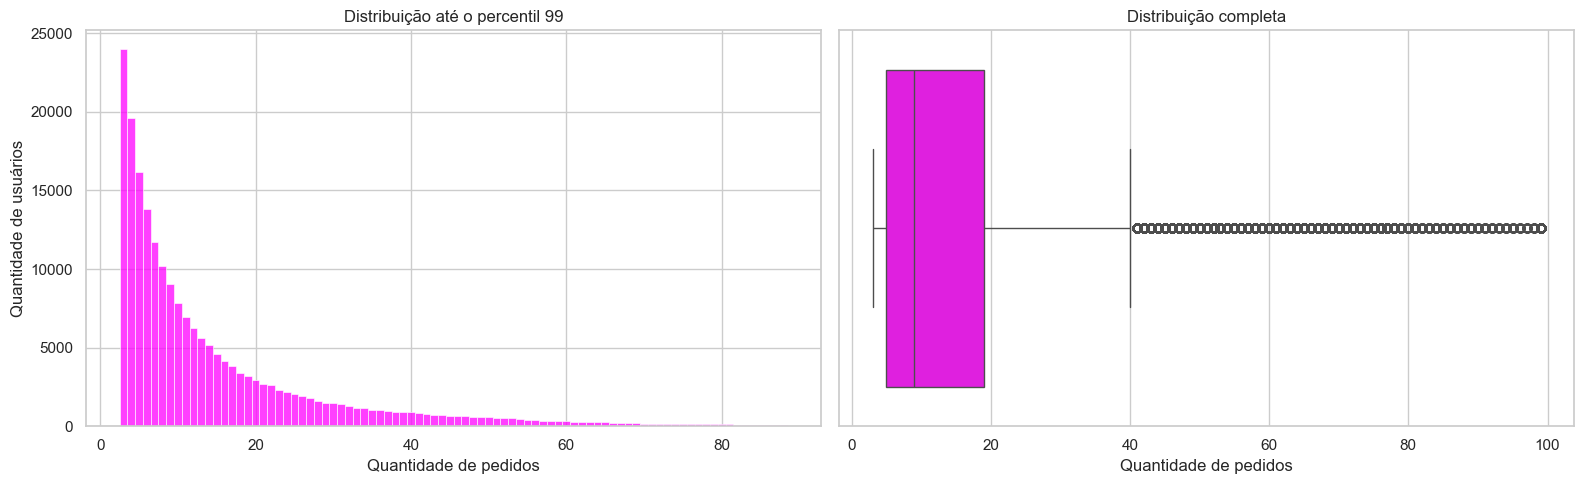

In [15]:
upper_limit = prior_user_order_counts["prior_order_count"].quantile(0.99)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histograma gráfico 1
sns.histplot(
    data=prior_user_order_counts[
        prior_user_order_counts["prior_order_count"] <= upper_limit
    ],
    x="prior_order_count",
    discrete=True,
    color="magenta",
    ax=axes[0],
)

axes[0].set_title("Distribuição até o percentil 99")
axes[0].set_xlabel("Quantidade de pedidos")
axes[0].set_ylabel("Quantidade de usuários")

# Boxplot gráfico 2
sns.boxplot(
    data=prior_user_order_counts,
    x="prior_order_count",
    color="magenta",
    ax=axes[1],
)

axes[1].set_title("Distribuição completa")
axes[1].set_xlabel("Quantidade de pedidos")

plt.tight_layout()
plt.show()

**Leituras a partir dos resultados**

- A distribuição de pedidos por usuário é assimétrica à direita: muitos usuários concentram-se em faixas menores de histórico, enquanto uma parcela menor possui quantidade bem maior de pedidos.
- Os valores extremos parecem representar usuários com alto engajamento, não necessariamente inconsistências.
- Apesar dessa concentração inicial, mais da metade dos usuários possui pelo menos 9 pedidos no histórico, o que indica uma base razoável para capturar preferências recorrentes.
- Usuários com poucos pedidos ainda podem gerar features menos estáveis, especialmente para sinais de recompra e frequência.

**Ações para Feature Engineering**

- Criar uma feature simples de profundidade histórica do usuário, como `user_prior_order_count`.
- Avaliar uma feature de comportamento médio de compra, como `user_avg_basket_size`.
- Avaliar uma feature de frequência/ritmo de compra, calculada sem usar o pedido alvo.
- Considerar segmentar usuários por faixas de histórico apenas para análise e diagnóstico, não necessariamente como feature inicial.
- Não remover usuários com muitos pedidos apenas por serem outliers; eles representam comportamento válido de alto engajamento.

### 3.3 Comportamento dos pedidos

**Pergunta analítica**: Como os carrinhos se comportam em tamanho e variabilidade?

**Objetivo**: Analisar a quantidade de itens por pedido para entender o tamanho típico dos carrinhos, a presença de pedidos muito pequenos ou muito grandes e possíveis diferenças entre os conjuntos `prior` e `train`.

O tamanho do carrinho é relevante para recomendação porque ajuda a entender quantos produtos os usuários costumam comprar por pedido e pode influenciar tanto features futuras quanto a escolha de métricas `@K`.

In [16]:
prior_order_item_counts = (
    df.loc[df["eval_set"] == "prior"]
    .groupby(["order_id", "user_id"])
    .agg(items_per_order=("product_id", "count"))
    .reset_index()
)

prior_order_item_counts.head()

,order_id,user_id,items_per_order
0,2,202279,9
1,3,205970,8
2,4,178520,13
3,5,156122,26
4,6,22352,3


In [17]:
prior_order_item_counts["items_per_order"].describe(
    percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

count   3,214,874.0000
mean           10.0889
std             7.5254
min             1.0000
1%              1.0000
5%              2.0000
10%             2.0000
25%             5.0000
50%             8.0000
75%            14.0000
90%            20.0000
95%            25.0000
99%            35.0000
max           145.0000
Name: items_per_order, dtype: float64

In [18]:
prior_order_item_counts["basket_size_segment"] = pd.cut(
    prior_order_item_counts["items_per_order"],
    bins=[0, 3, 6, 10, 15, 25, np.inf],
    labels=[
        "1-3 itens",
        "4-6 itens",
        "7-10 itens",
        "11-15 itens",
        "16-25 itens",
        "26+ itens",
    ],
)

basket_size_summary = (
    prior_order_item_counts["basket_size_segment"]
    .value_counts(sort=False)
    .rename_axis("basket_size_segment")
    .reset_index(name="orders")
)

basket_size_summary["orders_pct"] = (
    100 * basket_size_summary["orders"] / basket_size_summary["orders"].sum()
)

basket_size_summary

,basket_size_segment,orders,orders_pct
0,1-3 itens,550768,17.1319
1,4-6 itens,678086,21.0921
2,7-10 itens,773277,24.0531
3,11-15 itens,591239,18.3907
4,16-25 itens,478675,14.8894
5,26+ itens,142829,4.4428


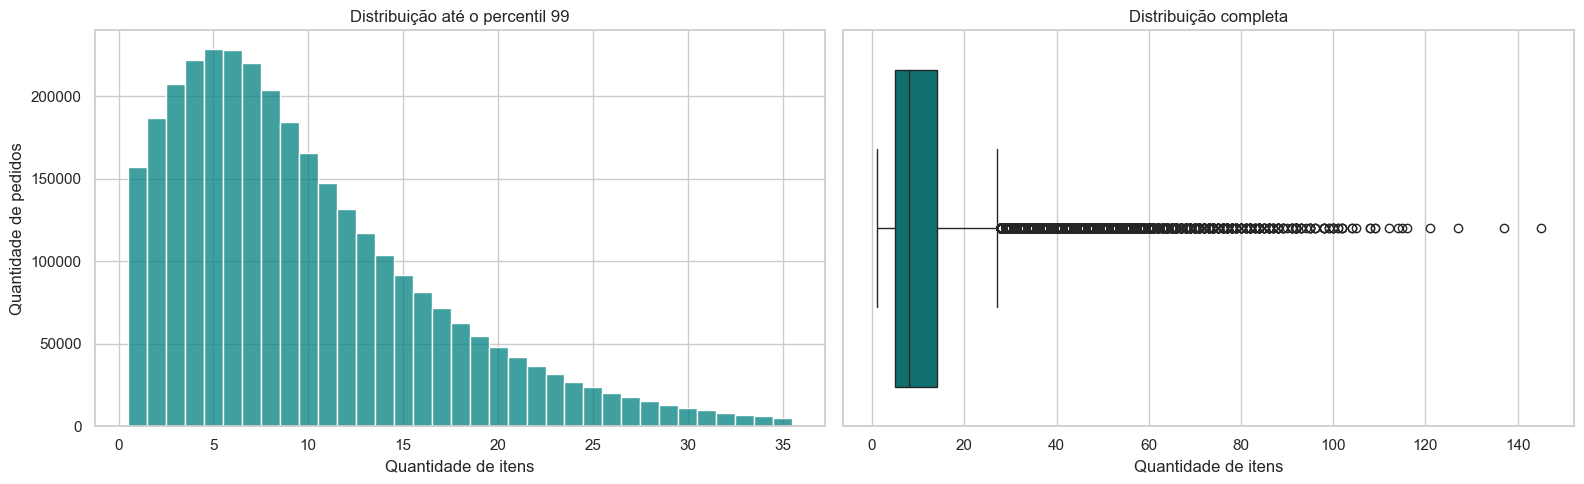

In [19]:
upper_limit = prior_order_item_counts["items_per_order"].quantile(0.99)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histograma gráfico 1
sns.histplot(
    data=prior_order_item_counts[
        prior_order_item_counts["items_per_order"] <= upper_limit
    ],
    x="items_per_order",
    discrete=True,
    color="teal",
    ax=axes[0],
)

axes[0].set_title("Distribuição até o percentil 99")
axes[0].set_xlabel("Quantidade de itens")
axes[0].set_ylabel("Quantidade de pedidos")

# Boxplot gráfico 2
sns.boxplot(
    data=prior_order_item_counts,
    x="items_per_order",
    color="teal",
    ax=axes[1],
)

axes[1].set_title("Distribuição completa")
axes[1].set_xlabel("Quantidade de itens")

plt.tight_layout()
plt.show()

**Leituras a partir dos resultados**

- Os pedidos do histórico `prior` possuem em média aproximadamente 10 itens, enquanto a mediana é 8 itens. Isso indica que a média é puxada para cima por pedidos maiores.
- Metade dos pedidos possui até 8 itens, e 75% dos pedidos possuem até 14 itens, mostrando que a maior parte dos carrinhos está concentrada em tamanhos moderados.
- A distribuição é assimétrica à direita: existem pedidos muito grandes, chegando a 145 itens, mas eles representam uma parcela pequena da base.
- O percentil 99 é de 35 itens, indicando que pedidos acima desse valor são extremos em relação ao comportamento típico.
- Os pedidos extremos parecem representar carrinhos grandes reais, não necessariamente inconsistências, portanto não devem ser removidos automaticamente no EDA.

**Ações para Feature Engineering**

- Avaliar a criação de uma feature histórica de tamanho médio do carrinho por usuário, como `user_avg_basket_size`.
- Considerar também uma versão mais robusta, como mediana de itens por pedido, caso a média seja muito influenciada por carrinhos extremos.
- Não remover pedidos grandes automaticamente; primeiro avaliar impacto em features e métricas futuras.
- Usar o tamanho típico dos carrinhos como referência na definição futura de métricas `@K`, já que um `K` muito baixo pode não representar bem pedidos com muitos itens.

### 3.4 Popularidade e concentração de produtos

**Pergunta analítica**: A demanda está concentrada em poucos produtos ou existe cauda longa forte?

**Objetivo**: Analisar a frequência histórica de compra dos produtos para entender quais itens concentram maior volume e como a demanda se distribui ao longo do catálogo.

Essa análise ajuda a avaliar se popularidade global pode ser um sinal útil para feature engineering, baseline e geração futura de candidatos.

In [20]:
prior_product_popularity = (
    df.loc[df["eval_set"] == "prior"]
    .groupby("product_id")
    .agg(
        product_name=("product_name", "first"),
        aisle=("aisle", "first"),
        department=("department", "first"),
        purchase_count=("order_id", "size"),
        user_count=("user_id", "nunique"),
    )
    .sort_values("purchase_count", ascending=False)
    .reset_index()
)

prior_product_popularity["purchase_pct"] = (
    100
    * prior_product_popularity["purchase_count"]
    / prior_product_popularity["purchase_count"].sum()
)

prior_product_popularity["cumulative_purchase_pct"] = prior_product_popularity[
    "purchase_pct"
].cumsum()

prior_product_popularity["product_rank"] = np.arange(
    1, len(prior_product_popularity) + 1
)

prior_product_popularity["catalog_pct"] = (
    100 * prior_product_popularity["product_rank"] / len(prior_product_popularity)
)

prior_product_popularity.head(20)

,product_id,product_name,aisle,department,purchase_count,user_count,purchase_pct,cumulative_purchase_pct,product_rank,catalog_pct
0,24852,Banana,fresh fruits,produce,472565,73956,1.4570,1.4570,1,0.0020
1,13176,Bag of Organic Bananas,fresh fruits,produce,379450,63537,1.1699,2.6269,2,0.0040
2,21137,Organic Strawberries,fresh fruits,produce,264683,58838,0.8161,3.4429,3,0.0060
3,21903,Organic Baby Spinach,packaged vegetables fruits,produce,241921,55037,0.7459,4.1888,4,0.0081
4,47209,Organic Hass Avocado,fresh fruits,produce,213584,43453,0.6585,4.8473,5,0.0101
5,47766,Organic Avocado,fresh fruits,produce,176815,42771,0.5451,5.3925,6,0.0121
6,47626,Large Lemon,fresh fruits,produce,152657,46402,0.4707,5.8631,7,0.0141
7,16797,Strawberries,fresh fruits,produce,142951,43149,0.4407,6.3039,8,0.0161
8,26209,Limes,fresh fruits,produce,140627,44859,0.4336,6.7374,9,0.0181
9,27845,Organic Whole Milk,milk,dairy eggs,137905,23395,0.4252,7.1626,10,0.0201


In [21]:
prior_product_popularity.tail(20)

,product_id,product_name,aisle,department,purchase_count,user_count,purchase_pct,cumulative_purchase_pct,product_rank,catalog_pct
49657,44748,Thick 'n Chunky Salsa Mild,condiments,pantry,1,1,0.0000,99.9999,49658,99.9618
49658,46278,Berry Sprouted Blend Cereal,cereal,breakfast,1,1,0.0000,99.9999,49659,99.9638
49659,43098,Buddy Bear Probiotic Orange Flavor Chewable,digestion,personal care,1,1,0.0000,99.9999,49660,99.9658
49660,30343,Seltzer Blueberry Lemonade,missing,missing,1,1,0.0000,100.0000,49661,99.9678
49661,9818,Cld/Flu Van Chrry,cold flu allergy,personal care,1,1,0.0000,100.0000,49662,99.9698
49662,28818,Hot Oatmeal Multigrain Raisin,hot cereal pancake mixes,breakfast,1,1,0.0000,100.0000,49663,99.9718
49663,7712,String Of Pearl White Sprinkles,baking supplies decor,pantry,1,1,0.0000,100.0000,49664,99.9738
49664,4417,Organic Veggie Ground,tofu meat alternatives,deli,1,1,0.0000,100.0000,49665,99.9758
49665,47408,Control GX Gray Reducing Shampoo,missing,missing,1,1,0.0000,100.0000,49666,99.9779
49666,14485,Organic Ice Cream Birthday Cake,ice cream ice,frozen,1,1,0.0000,100.0000,49667,99.9799


In [22]:
concentration_thresholds = [50, 80, 90, 95]

product_concentration_summary = pd.DataFrame(
    [
        {
            "purchase_threshold_pct": threshold,
            "products_needed": (
                prior_product_popularity["cumulative_purchase_pct"]
                .ge(threshold)
                .idxmax()
                + 1
            ),  # Qtde de produtos necessário p/ chegar no volume de compra do threshold
        }
        for threshold in concentration_thresholds
    ]
)

# Porcentagem de produto necessário para chegar no threshold%
product_concentration_summary["catalog_pct"] = (
    100
    * product_concentration_summary["products_needed"]
    / len(prior_product_popularity)
)

product_concentration_summary

,purchase_threshold_pct,products_needed,catalog_pct
0,50,787,1.5842
1,80,4538,9.1350
2,90,9152,18.4230
3,95,14818,29.8287


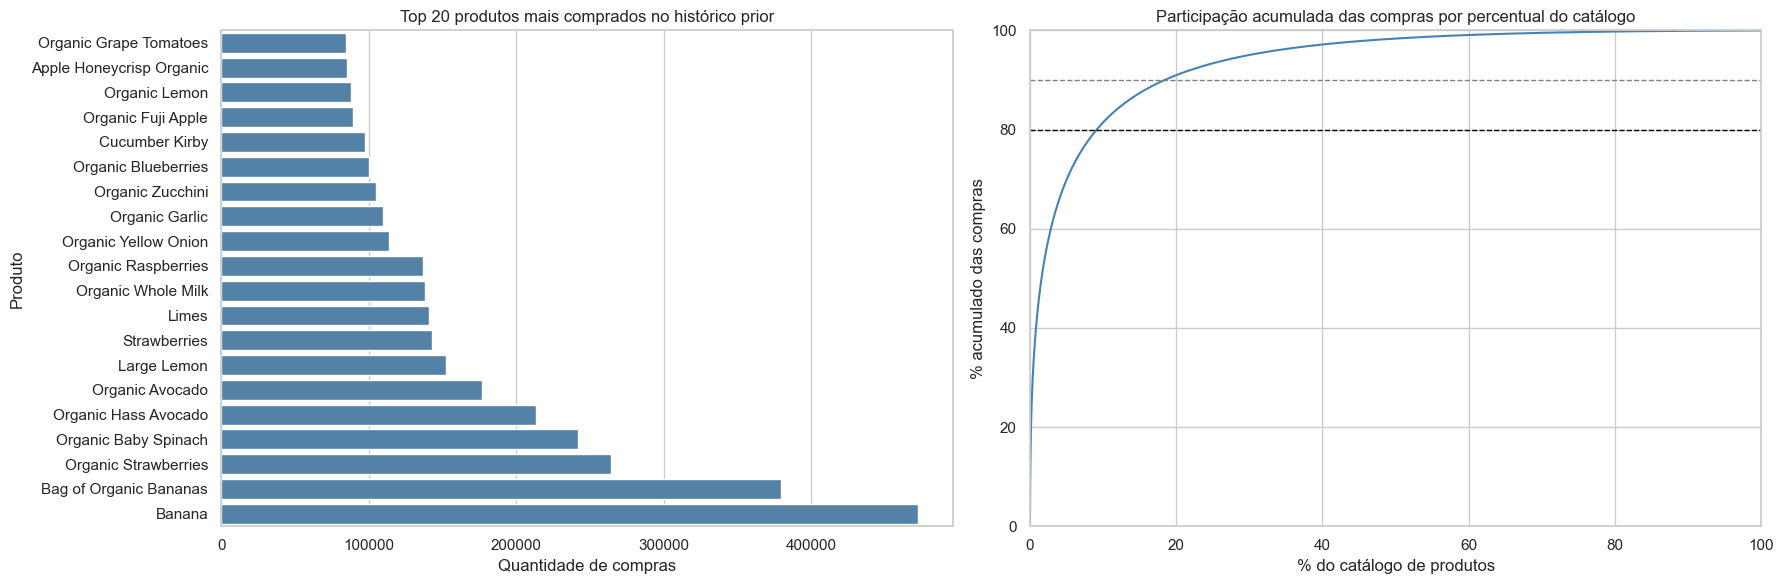

In [23]:
top_n = 20
top_products = prior_product_popularity.head(top_n).sort_values("purchase_count")

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(
    data=top_products,
    x="purchase_count",
    y="product_name",
    color="steelblue",
    ax=axes[0],
)

axes[0].set_title(f"Top {top_n} produtos mais comprados no histórico prior")
axes[0].set_xlabel("Quantidade de compras")
axes[0].set_ylabel("Produto")

sns.lineplot(
    data=prior_product_popularity,
    x="catalog_pct",
    y="cumulative_purchase_pct",
    color="steelblue",
    ax=axes[1],
)

axes[1].axhline(80, linestyle="--", color="black", linewidth=1)
axes[1].axhline(90, linestyle="--", color="gray", linewidth=1)

axes[1].set_title("Participação acumulada das compras por percentual do catálogo")
axes[1].set_xlabel("% do catálogo de produtos")
axes[1].set_ylabel("% acumulado das compras")
axes[1].set_xlim(0, 100)
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.show()

**Leituras a partir dos resultados**

- A demanda histórica é concentrada nos produtos mais populares, mas existe uma cauda longa relevante de produtos com baixo volume.
- Os produtos no topo do ranking concentram uma parcela relevante das compras históricas, indicando que popularidade global pode ser um sinal competitivo para baseline.
- São necessários aproximadamente `4.538` produtos para explicar 80% das compras, `9.152` produtos para 90% e `14.818` produtos para 95%, mostrando o grau de concentração do catálogo. Essa quantidade de produto representa aproximadamente 9%, 18%, 30% respectivamente do catalogo para explicar tal porcentagem das compras.
- A presença de muitos produtos com baixo volume reforça que rankings baseados apenas em taxa ou frequência podem ser instáveis na cauda.


**Ações para Feature Engineering**

- Criar uma feature histórica de popularidade do produto, como `product_prior_purchase_count` ou `product_popularity`.
- Avaliar uma versão normalizada da popularidade, como percentual de compras do produto no histórico.
- Usar popularidade global como baseline simples futuro.
- Considerar a cauda longa na estratégia futura de candidatos, evitando depender apenas dos produtos mais populares.

### 3.5 Categorias: aisles e departments

**Pergunta analítica**: As categorias explicam diferenças relevantes no comportamento de compra?

**Objetivo**: Analisar a frequência histórica de compras por `aisle` e `department` para entender se categorias concentram volume e podem ajudar a resumir preferências dos usuários.

Categorias são úteis porque reduzem a granularidade em relação ao produto. Mesmo quando há pouco histórico para um produto específico, o comportamento por categoria pode fornecer sinais mais estáveis para feature engineering e estratégias futuras de fallback.

In [24]:
prior_aisle_popularity = (
    df.loc[df["eval_set"] == "prior"]
    .groupby(["aisle_id", "aisle"])
    .agg(
        purchase_count=("order_id", "size"),
        user_count=("user_id", "nunique"),
        product_count=("product_id", "nunique"),
    )
    .sort_values("purchase_count", ascending=False)
    .reset_index()
)

prior_aisle_popularity["purchase_pct"] = (
    100
    * prior_aisle_popularity["purchase_count"]
    / prior_aisle_popularity["purchase_count"].sum()
)

prior_aisle_popularity["cumulative_purchase_pct"] = prior_aisle_popularity[
    "purchase_pct"
].cumsum()

prior_aisle_popularity.head(20)

,aisle_id,aisle,purchase_count,user_count,product_count,purchase_pct,cumulative_purchase_pct
0,24,fresh fruits,3642188,177141,382,11.2294,11.2294
1,83,fresh vegetables,3418021,159213,569,10.5382,21.7676
2,123,packaged vegetables fruits,1765313,159418,615,5.4427,27.2103
3,120,yogurt,1452343,124393,1026,4.4778,31.6881
4,21,packaged cheese,979763,132973,890,3.0207,34.7088
5,84,milk,891015,109226,243,2.7471,37.4559
6,115,water seltzer sparkling water,841533,99755,344,2.5946,40.0505
7,107,chips pretzels,722470,111930,989,2.2275,42.2780
8,91,soy lactosefree,638253,96326,293,1.9678,44.2458
9,112,bread,584834,103565,557,1.8031,46.0489


In [25]:
prior_department_popularity = (
    df.loc[df["eval_set"] == "prior"]
    .groupby(["department_id", "department"])
    .agg(
        purchase_count=("order_id", "size"),
        user_count=("user_id", "nunique"),
        product_count=("product_id", "nunique"),
    )
    .sort_values("purchase_count", ascending=False)
    .reset_index()
)

prior_department_popularity["purchase_pct"] = (
    100
    * prior_department_popularity["purchase_count"]
    / prior_department_popularity["purchase_count"].sum()
)

prior_department_popularity["cumulative_purchase_pct"] = prior_department_popularity[
    "purchase_pct"
].cumsum()

prior_department_popularity

,department_id,department,purchase_count,user_count,product_count,purchase_pct,cumulative_purchase_pct
0,4,produce,9479291,193237,1684,29.2260,29.2260
1,16,dairy eggs,5414016,190565,3448,16.6922,45.9181
2,19,snacks,2887550,174219,6263,8.9027,54.8208
3,7,beverages,2690129,172795,4363,8.2940,63.1149
4,1,frozen,2236432,163233,4007,6.8952,70.0101
5,13,pantry,1875577,172755,5370,5.7827,75.7928
6,3,bakery,1176787,140612,1516,3.6282,79.4210
7,15,canned goods,1068058,133733,2092,3.2930,82.7139
8,20,deli,1051249,133865,1322,3.2411,85.9551
9,9,dry goods pasta,866627,124820,1858,2.6719,88.6270


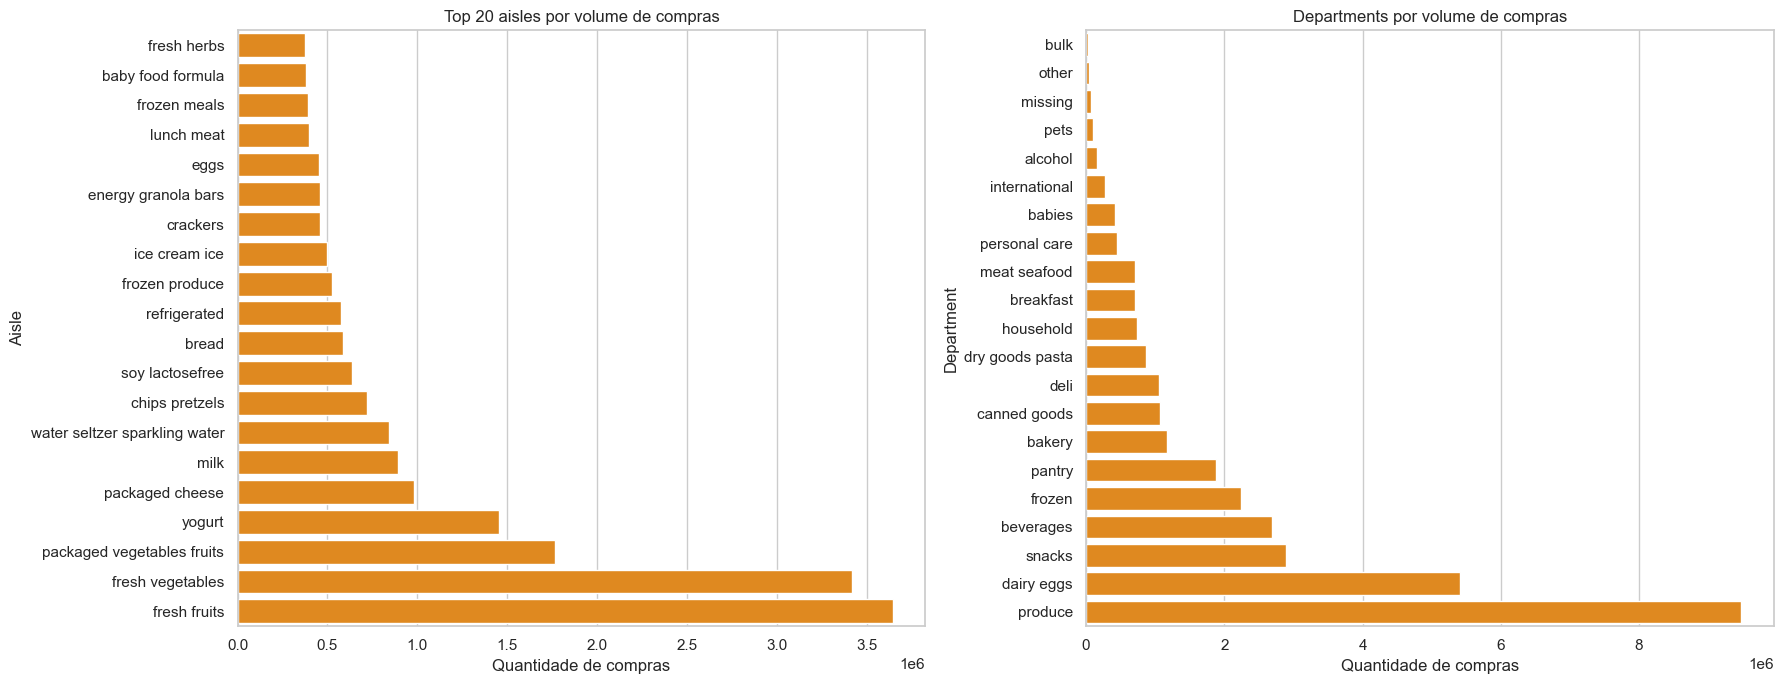

In [26]:
top_n_aisles = 20

top_aisles = prior_aisle_popularity.head(top_n_aisles).sort_values("purchase_count")

top_departments = prior_department_popularity.sort_values("purchase_count")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(
    data=top_aisles,
    x="purchase_count",
    y="aisle",
    color="darkorange",
    ax=axes[0],
)

axes[0].set_title(f"Top {top_n_aisles} aisles por volume de compras")
axes[0].set_xlabel("Quantidade de compras")
axes[0].set_ylabel("Aisle")

sns.barplot(
    data=top_departments,
    x="purchase_count",
    y="department",
    color="darkorange",
    ax=axes[1],
)

axes[1].set_title("Departments por volume de compras")
axes[1].set_xlabel("Quantidade de compras")
axes[1].set_ylabel("Department")

plt.tight_layout()
plt.show()

In [27]:
category_concentration_summary = pd.DataFrame(
    {
        "level": ["aisle", "department"],
        "categories": [
            prior_aisle_popularity["aisle_id"].nunique(),
            prior_department_popularity["department_id"].nunique(),
        ],
        "top_5_purchase_pct": [
            prior_aisle_popularity.head(5)["purchase_pct"].sum(),
            prior_department_popularity.head(5)["purchase_pct"].sum(),
        ],
        "top_10_purchase_pct": [
            prior_aisle_popularity.head(10)["purchase_pct"].sum(),
            prior_department_popularity.head(10)["purchase_pct"].sum(),
        ],
        "top_25_purchase_pct": [
            prior_aisle_popularity.head(25)["purchase_pct"].sum(),
            prior_department_popularity.head(25)["purchase_pct"].sum(),
        ],
    }
)

category_concentration_summary

,level,categories,top_5_purchase_pct,top_10_purchase_pct,top_25_purchase_pct
0,aisle,134,34.7088,46.0489,65.4146
1,department,21,70.0101,88.6270,100.0000


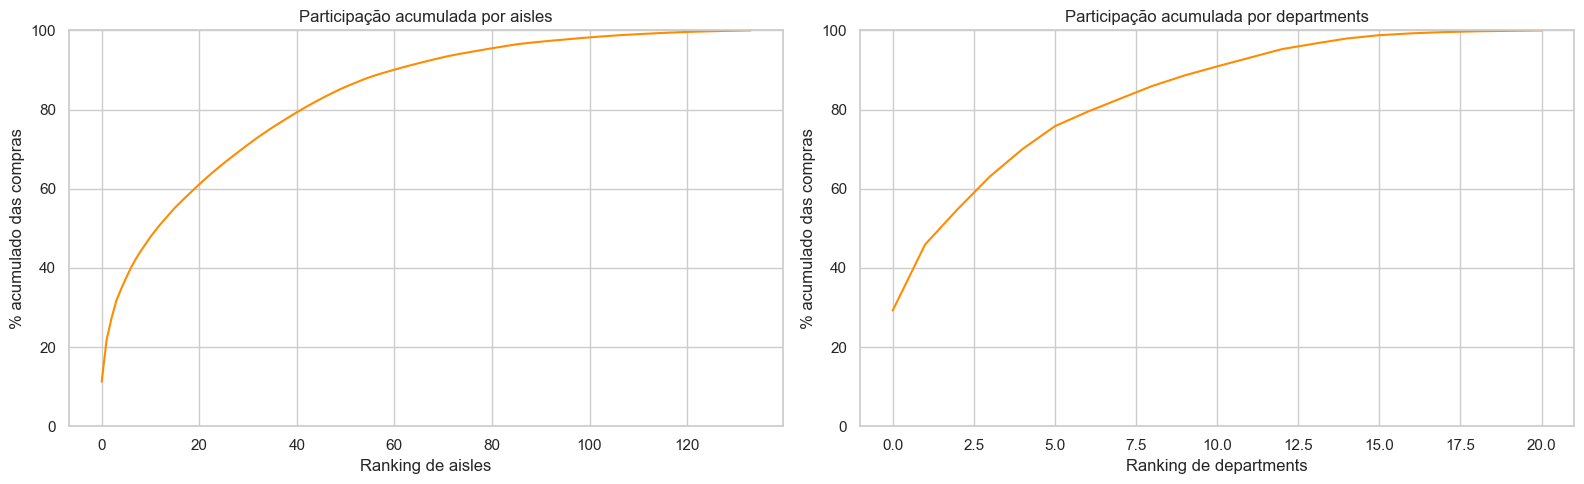

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.lineplot(
    data=prior_aisle_popularity.reset_index(),
    x="index",
    y="cumulative_purchase_pct",
    color="darkorange",
    ax=axes[0],
)

axes[0].set_title("Participação acumulada por aisles")
axes[0].set_xlabel("Ranking de aisles")
axes[0].set_ylabel("% acumulado das compras")
axes[0].set_ylim(0, 100)

sns.lineplot(
    data=prior_department_popularity.reset_index(),
    x="index",
    y="cumulative_purchase_pct",
    color="darkorange",
    ax=axes[1],
)

axes[1].set_title("Participação acumulada por departments")
axes[1].set_xlabel("Ranking de departments")
axes[1].set_ylabel("% acumulado das compras")
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.show()

**Leituras a partir dos resultados**

- A demanda também apresenta concentração por categorias: poucos aisles e departments representam uma parcela relevante das compras.
- `Aisle` oferece uma granularidade intermediária entre produto e department, podendo capturar preferências mais específicas sem depender exclusivamente do histórico de cada produto.
- `Departments` resumem bem grandes blocos de comportamento, mas podem perder especificidade para recomendação final.
- Como categorias agregam muitos produtos, suas estatísticas tendem a ser mais estáveis do que estatísticas de produtos raros.

**Ações para Feature Engineering**

- Avaliar features históricas de preferência do usuário por categoria, como frequência de compras por `aisle` e `department`.
- Avaliar popularidade histórica de `aisle` e `department` como sinais agregados.
- Considerar categorias como apoio para estratégias futuras de candidatos ou fallback.
- Usar categorias como complemento ao produto, não como substituição completa da informação em nível `product_id`.

### 3.6 Recompra

**Pergunta analítica**: Recompra é um sinal forte para prever o próximo carrinho?

**Objetivo**: Analisar o comportamento de recompra no histórico `prior` em diferentes níveis de agregação: geral, produto, usuário e categoria.

A coluna `reordered` indica se um produto comprado em um pedido já havia sido comprado anteriormente pelo mesmo usuário. Como essa coluna é binária, sua média representa a taxa de recompra em nível de item comprado.

In [29]:
prior_product_reorder = (
    df.loc[df["eval_set"] == "prior"]
    .groupby("product_id")
    .agg(
        product_name=("product_name", "first"),
        aisle=("aisle", "first"),
        department=("department", "first"),
        purchase_count=("order_id", "size"),
        user_count=("user_id", "nunique"),
        reorder_count=("reordered", "sum"),
        reorder_rate=("reordered", "mean"),
    )
    .sort_values("purchase_count", ascending=False)
    .reset_index()
)

prior_product_reorder.head(20)

,product_id,product_name,aisle,department,purchase_count,user_count,reorder_count,reorder_rate
0,24852,Banana,fresh fruits,produce,472565,73956,398609,0.8435
1,13176,Bag of Organic Bananas,fresh fruits,produce,379450,63537,315913,0.8326
2,21137,Organic Strawberries,fresh fruits,produce,264683,58838,205845,0.7777
3,21903,Organic Baby Spinach,packaged vegetables fruits,produce,241921,55037,186884,0.7725
4,47209,Organic Hass Avocado,fresh fruits,produce,213584,43453,170131,0.7966
5,47766,Organic Avocado,fresh fruits,produce,176815,42771,134044,0.7581
6,47626,Large Lemon,fresh fruits,produce,152657,46402,106255,0.6960
7,16797,Strawberries,fresh fruits,produce,142951,43149,99802,0.6982
8,26209,Limes,fresh fruits,produce,140627,44859,95768,0.6810
9,27845,Organic Whole Milk,milk,dairy eggs,137905,23395,114510,0.8304


In [30]:
prior_product_reorder["purchase_count"].describe()

count    49,677.0000
mean        652.9076
std       4,792.1144
min           1.0000
25%          17.0000
50%          60.0000
75%         260.0000
max     472,565.0000
Name: purchase_count, dtype: float64

In [31]:
volume_thresholds = [100, 500, 1_000, 5_000, 10_000]

product_volume_threshold_summary = pd.DataFrame(
    {
        "min_purchase_count": volume_thresholds,
        "products": [
            (prior_product_reorder["purchase_count"] >= threshold).sum()
            for threshold in volume_thresholds
        ],
    }
)

product_volume_threshold_summary["products_pct"] = (
    100 * product_volume_threshold_summary["products"] / len(prior_product_reorder)
)

product_volume_threshold_summary

,min_purchase_count,products,products_pct
0,100,20067,40.3950
1,500,8290,16.6878
2,1000,5058,10.1818
3,5000,1094,2.2022
4,10000,492,0.9904


O ranking de produtos por taxa de recompra precisa considerar um volume mínimo de compras.

Sem esse filtro, produtos raros podem aparecer no topo com taxa de recompra artificialmente alta, mesmo tendo poucas observações. O corte mínimo abaixo deve ser definido com base na distribuição de volume dos produtos e na quantidade de produtos preservados após o filtro.

Foi adotado um limiar mínimo de 100 compras para o ranking de taxa de recompra por produto.

Esse valor está acima da mediana de compras por produto e preserva aproximadamente 40% do catálogo, reduzindo o efeito de produtos raros sem restringir a análise apenas aos itens extremamente populares.

In [32]:
min_product_purchases = 100

prior_product_reorder_filtered = prior_product_reorder[
    prior_product_reorder["purchase_count"] >= min_product_purchases
].copy()

top_reordered_products = prior_product_reorder_filtered.sort_values(
    "reorder_rate", ascending=False
).head(20)

top_reordered_products[
    [
        "product_name",
        "aisle",
        "department",
        "purchase_count",
        "user_count",
        "reorder_count",
        "reorder_rate",
    ]
]

,product_name,aisle,department,purchase_count,user_count,reorder_count,reorder_rate
19976,Chocolate Love Bar,candy chocolate,snacks,101,8,93,0.9208
20021,Maca Buttercups,candy chocolate,snacks,100,10,90,0.9000
19117,Benchbreak Chardonnay,white wines,alcohol,111,12,99,0.8919
17762,Fragrance Free Clay with Natural Odor Eliminat...,cat food care,pets,129,16,113,0.8760
18972,Thousand Island Salad Snax,fruit vegetable snacks,snacks,112,14,98,0.8750
8887,Real2 Alkalized Water 500 ml,water seltzer sparkling water,beverages,451,62,389,0.8625
1948,Half And Half Ultra Pasteurized,milk,dairy eggs,2921,404,2517,0.8617
536,Whole Organic Omega 3 Milk,milk,dairy eggs,9108,1273,7835,0.8602
587,Organic Lactose Free Whole Milk,soy lactosefree,dairy eggs,8477,1195,7282,0.8590
1434,Organic Homogenized Whole Milk,milk,dairy eggs,3970,565,3405,0.8577


In [33]:
prior_user_reorder = (
    df.loc[df["eval_set"] == "prior"]
    .groupby("user_id")
    .agg(
        purchased_items=("order_id", "size"),
        reordered_items=("reordered", "sum"),
        user_reorder_rate=("reordered", "mean"),
    )
    .reset_index()
)

prior_user_reorder["user_reorder_rate"].describe(
    percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

count   206,209.0000
mean          0.4322
std           0.2121
min           0.0000
1%            0.0000
5%            0.0909
10%           0.1471
25%           0.2679
50%           0.4286
75%           0.5957
90%           0.7207
95%           0.7795
99%           0.8628
max           0.9895
Name: user_reorder_rate, dtype: float64

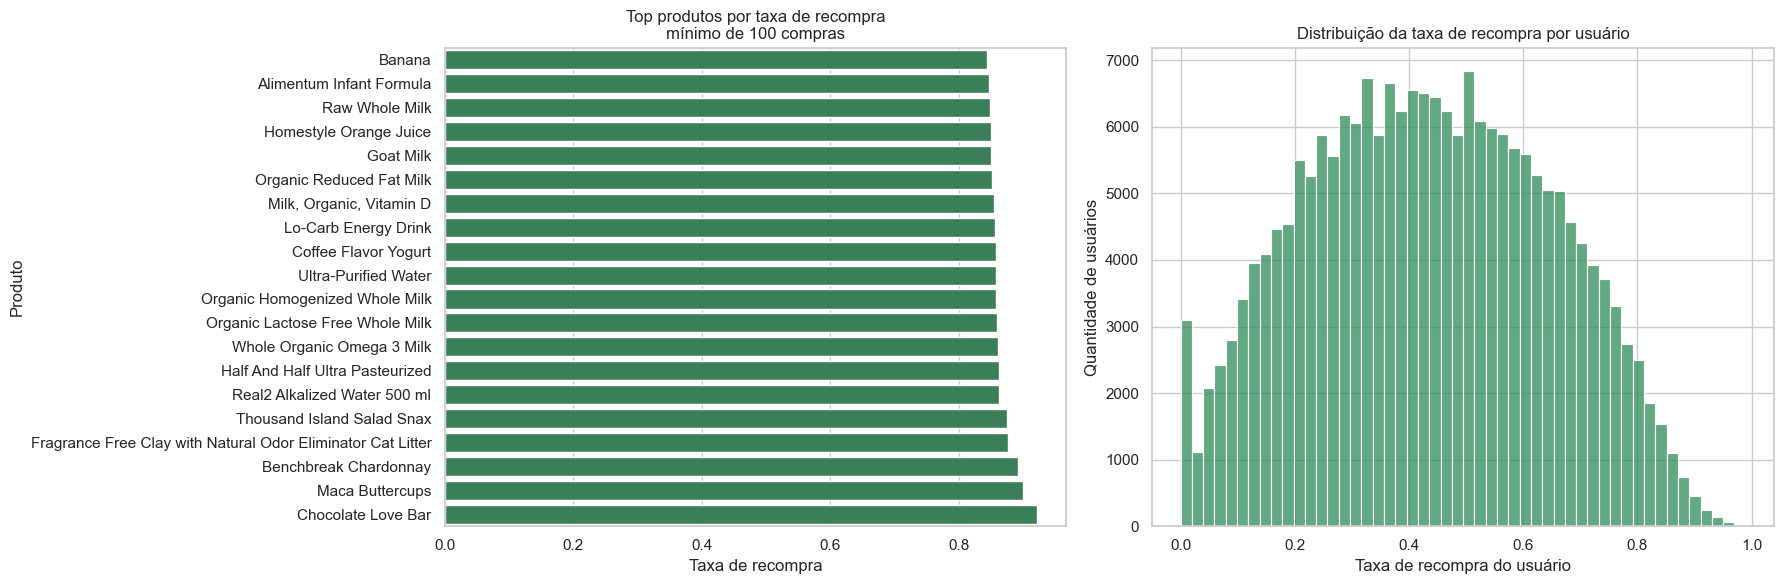

In [34]:
top_reordered_products_plot = top_reordered_products.sort_values("reorder_rate")

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(
    data=top_reordered_products_plot,
    x="reorder_rate",
    y="product_name",
    color="seagreen",
    ax=axes[0],
)

axes[0].set_title(
    f"Top produtos por taxa de recompra\nmínimo de {min_product_purchases:,} compras"
)
axes[0].set_xlabel("Taxa de recompra")
axes[0].set_ylabel("Produto")

sns.histplot(
    data=prior_user_reorder,
    x="user_reorder_rate",
    bins=50,
    color="seagreen",
    ax=axes[1],
)

axes[1].set_title("Distribuição da taxa de recompra por usuário")
axes[1].set_xlabel("Taxa de recompra do usuário")
axes[1].set_ylabel("Quantidade de usuários")

plt.tight_layout()
plt.show()

**Leituras a partir dos resultados**

- A taxa geral de recompra no histórico `prior` indica que a recompra é um comportamento relevante na base transacional.
- Popularidade e recompra medem fenômenos diferentes: produtos muito comprados não são necessariamente os produtos com maior taxa de recompra.
- O filtro mínimo de volume é necessário para interpretar rankings de taxa de recompra, pois produtos raros podem apresentar taxas artificialmente altas.
- A análise por usuário mostra se existem perfis mais recorrentes ou mais exploratórios, o que pode influenciar a estabilidade de features comportamentais.
- Categorias com alta taxa de recompra podem fornecer sinais agregados mais estáveis do que produtos individuais, especialmente para produtos com pouco volume.
- A recompra parece ser um dos sinais mais importantes para orientar a etapa futura de feature engineering.

**Ações para Feature Engineering**

- Criar features históricas em nível `user_id-product_id`, como `user_product_purchase_count`.
- Avaliar uma feature simples indicando se o usuário já comprou o produto anteriormente.
- Criar features agregadas por produto, como `product_prior_purchase_count` e `product_prior_reorder_rate`.
- Avaliar features de comportamento do usuário, como `user_reorder_rate`, calculadas apenas com histórico anterior ao pedido alvo.
- Avaliar features agregadas de recompra por `aisle` e `department`.
- Aplicar filtros, transformações ou suavização em taxas de recompra com baixo volume para evitar sinais instáveis.

### 3.7 Temporalidade

**Pergunta analítica**: Quando os usuários compram e qual é o ritmo de recompra?

**Objetivo**: Analisar padrões temporais dos pedidos no histórico `prior`, considerando dia da semana, hora do dia e intervalo desde o pedido anterior.

Como o dataset está em nível `pedido-produto`, esta seção usa pedidos únicos para evitar que carrinhos maiores tenham peso desproporcional na análise temporal.

In [35]:
prior_order_temporal = (
    df.loc[
        df["eval_set"] == "prior",
        [
            "order_id",
            "user_id",
            "order_number",
            "order_dow",
            "order_hour_of_day",
            "days_since_prior_order",
        ],
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

prior_order_temporal.head()

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2,202279,3,5,9,8.0000
1,3,205970,16,5,17,12.0000
2,4,178520,36,1,9,7.0000
3,5,156122,42,6,16,9.0000
4,6,22352,4,1,12,30.0000


In [36]:
prior_order_temporal["days_since_prior_order"].describe(
    percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

count   3,008,665.0000
mean           10.7072
std             8.9542
min             0.0000
1%              0.0000
5%              1.0000
10%             2.0000
25%             4.0000
50%             7.0000
75%            15.0000
90%            30.0000
95%            30.0000
99%            30.0000
max            30.0000
Name: days_since_prior_order, dtype: float64

In [37]:
dow_summary = (
    prior_order_temporal["order_dow"]
    .value_counts()
    .sort_index()
    .rename_axis("order_dow")
    .reset_index(name="orders")
)

dow_summary["orders_pct"] = 100 * dow_summary["orders"] / dow_summary["orders"].sum()

dow_summary

,order_dow,orders,orders_pct
0,0,557772,17.3497
1,1,556705,17.3165
2,2,441955,13.7472
3,3,412400,12.8279
4,4,401212,12.4799
5,5,425982,13.2503
6,6,418848,13.0284


In [38]:
hour_summary = (
    prior_order_temporal["order_hour_of_day"]
    .value_counts()
    .sort_index()
    .rename_axis("order_hour_of_day")
    .reset_index(name="orders")
)

hour_summary["orders_pct"] = 100 * hour_summary["orders"] / hour_summary["orders"].sum()

hour_summary

,order_hour_of_day,orders,orders_pct
0,0,21372,0.6648
1,1,11596,0.3607
2,2,7070,0.2199
3,3,5120,0.1593
4,4,5175,0.1610
5,5,8972,0.2791
6,6,28792,0.8956
7,7,86656,2.6955
8,8,168321,5.2357
9,9,243496,7.5740


In [39]:
dow_hour_matrix = prior_order_temporal.pivot_table(
    index="order_dow",
    columns="order_hour_of_day",
    values="order_id",
    aggfunc="count",
    fill_value=0,
)

dow_hour_matrix_pct = 100 * dow_hour_matrix / dow_hour_matrix.values.sum()

dow_hour_matrix_pct

order_hour_of_day,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
order_dow,,,,,,,,,,,,,,,,,,,,,,,,
0,0.1148,0.0695,0.0404,0.0276,0.0233,0.0335,0.0976,0.3586,0.8157,1.1817,1.3997,1.4731,1.4846,1.5552,1.5703,1.5559,1.4287,1.1470,0.8506,0.6523,0.5283,0.4176,0.3247,0.1989
1,0.1081,0.0540,0.0331,0.0221,0.0237,0.0474,0.1587,0.4912,1.0129,1.5407,1.6486,1.5244,1.3857,1.3759,1.3755,1.3659,1.3126,1.0766,0.8490,0.6509,0.4797,0.3512,0.2631,0.1655
2,0.0904,0.0462,0.0277,0.0211,0.0218,0.0414,0.1407,0.3904,0.7306,1.0731,1.1589,1.1256,1.0499,1.0777,1.0919,1.1014,1.1037,0.9399,0.7741,0.5886,0.4424,0.3133,0.2386,0.1580
3,0.0861,0.0438,0.0277,0.0188,0.0207,0.0393,0.1342,0.3651,0.6627,0.9535,1.0581,1.0350,0.9823,1.0014,1.0222,1.0548,1.0353,0.8902,0.7321,0.5632,0.4064,0.3023,0.2405,0.1523
4,0.0770,0.0440,0.0260,0.0199,0.0216,0.0389,0.1286,0.3678,0.6407,0.9221,1.0282,0.9907,0.9436,0.9574,0.9850,0.9983,1.0008,0.8578,0.7114,0.5659,0.4153,0.3163,0.2574,0.1651
5,0.0930,0.0479,0.0296,0.0248,0.0267,0.0456,0.1422,0.3916,0.7037,1.0034,1.1262,1.1103,1.0421,1.0612,1.0928,1.0955,1.0483,0.8736,0.7061,0.5447,0.3906,0.2786,0.2179,0.1541
6,0.0954,0.0554,0.0354,0.0249,0.0232,0.0330,0.0935,0.3307,0.6695,0.8995,1.0374,1.0774,1.0811,1.0951,1.1226,1.1064,1.0320,0.8740,0.6956,0.5284,0.3891,0.3050,0.2476,0.1761


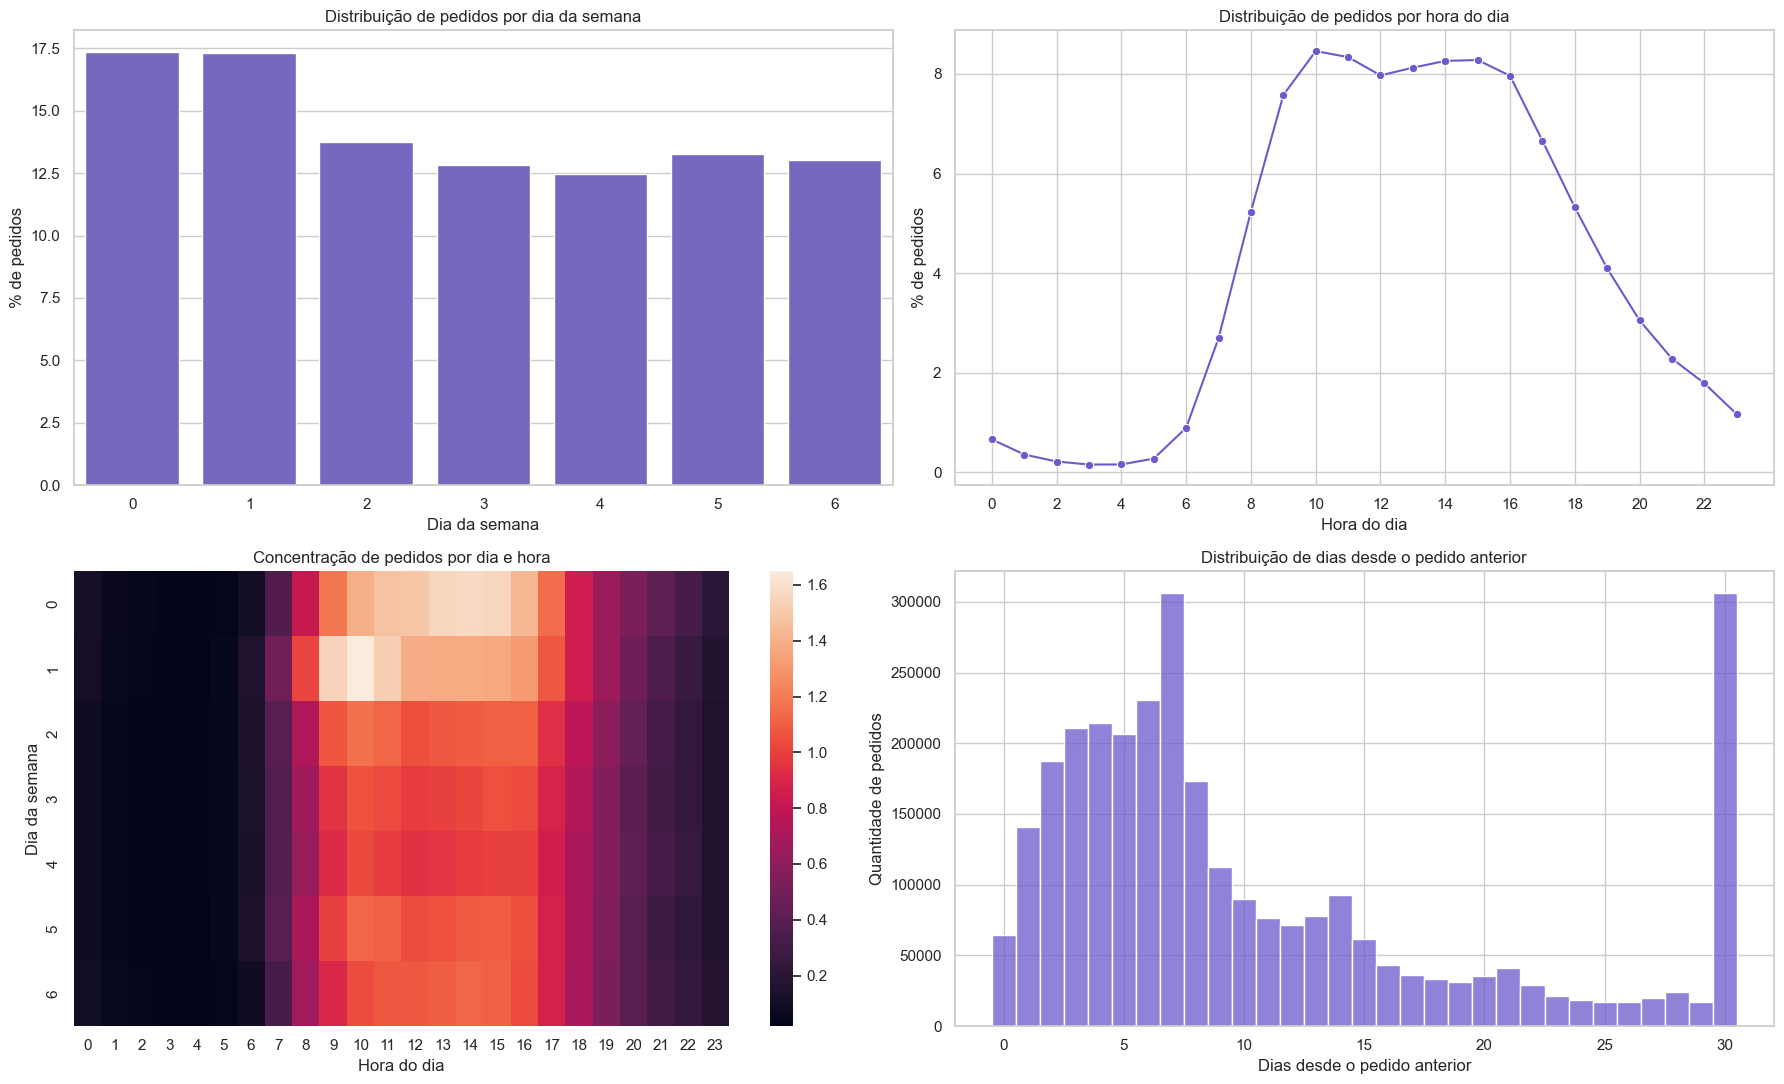

In [40]:
fig, axes = plt.subplots(2, 2, figsize=(18, 11))

sns.barplot(
    data=dow_summary,
    x="order_dow",
    y="orders_pct",
    color="slateblue",
    ax=axes[0, 0],
)

axes[0, 0].set_title("Distribuição de pedidos por dia da semana")
axes[0, 0].set_xlabel("Dia da semana")
axes[0, 0].set_ylabel("% de pedidos")

sns.lineplot(
    data=hour_summary,
    x="order_hour_of_day",
    y="orders_pct",
    marker="o",
    color="slateblue",
    ax=axes[0, 1],
)

axes[0, 1].set_title("Distribuição de pedidos por hora do dia")
axes[0, 1].set_xlabel("Hora do dia")
axes[0, 1].set_ylabel("% de pedidos")
axes[0, 1].set_xticks(range(0, 24, 2))

sns.heatmap(
    dow_hour_matrix_pct,
    cmap="rocket",
    ax=axes[1, 0],
)

axes[1, 0].set_title("Concentração de pedidos por dia e hora")
axes[1, 0].set_xlabel("Hora do dia")
axes[1, 0].set_ylabel("Dia da semana")

sns.histplot(
    data=prior_order_temporal.dropna(subset=["days_since_prior_order"]),
    x="days_since_prior_order",
    discrete=True,
    color="slateblue",
    ax=axes[1, 1],
)

axes[1, 1].set_title("Distribuição de dias desde o pedido anterior")
axes[1, 1].set_xlabel("Dias desde o pedido anterior")
axes[1, 1].set_ylabel("Quantidade de pedidos")

plt.tight_layout()
plt.show()

**Leituras a partir dos resultados**

- A distribuição por `order_dow` indica concentração maior em alguns dias da semana, sugerindo padrão temporal de compra.
- A distribuição por `order_hour_of_day` mostra maior volume de pedidos em determinadas faixas horárias.
- O heatmap ajuda a identificar combinações específicas de dia e hora com maior volume de compras.
- A distribuição de `days_since_prior_order` indica o ritmo típico de retorno dos usuários entre pedidos.
- Os valores ausentes em `days_since_prior_order` são esperados em primeiros pedidos conhecidos e devem ser tratados com cuidado na etapa de Feature Engineering.

**Ações para Feature Engineering**

- Avaliar features de recência, como `days_since_prior_order`, garantindo tratamento explícito para valores ausentes.
- Avaliar features de frequência de compra por usuário, como intervalo médio ou mediano entre pedidos.
- Considerar sinais temporais simples, como hora do pedido e dia da semana, se forem disponíveis no momento da recomendação.
- Criar flags ou imputações para primeiros pedidos apenas no notebook de Feature Engineering, evitando decisões prematuras no EDA.

---

## 4. Diagnósticos para modelagem futura

Nesta seção, o objetivo é registrar diagnósticos exploratórios que impactam a próxima etapa do projeto: construção do dataset de modelagem, definição de features históricas, criação de candidatos e avaliação futura.

As análises continuam sendo exploratórias. Este notebook não cria o dataset `user_id-product_id`.

### 4.1 Esparsidade user-product

**Pergunta analítica**: Quão esparsa é a relação usuário-produto que futuramente será usada na modelagem?

**Objetivo**: Estimar a densidade da matriz usuário-produto observada no histórico `prior`.

Em sistemas de recomendação, a maioria dos usuários interage com apenas uma pequena fração do catálogo. Medir essa esparsidade ajuda a dimensionar o desafio de modelagem e reforça a necessidade futura de estratégia de candidatos e exemplos negativos.

In [41]:
prior_user_product_pairs = df.loc[
    df["eval_set"] == "prior", ["user_id", "product_id"]
].drop_duplicates()

n_users = df.loc[df["eval_set"] == "prior", "user_id"].nunique()
n_products = df.loc[df["eval_set"] == "prior", "product_id"].nunique()
n_observed_user_product_pairs = len(prior_user_product_pairs)
n_possible_user_product_pairs = n_users * n_products

user_product_density = n_observed_user_product_pairs / n_possible_user_product_pairs

user_product_sparsity = 1 - user_product_density

sparsity_summary = pd.DataFrame(
    {
        "metric": [
            "Usuários únicos",
            "Produtos únicos",
            "Pares user-product observados",
            "Pares user-product possíveis",
            "Densidade observada",
            "Esparsidade estimada",
        ],
        "value": [
            n_users,
            n_products,
            n_observed_user_product_pairs,
            n_possible_user_product_pairs,
            user_product_density,
            user_product_sparsity,
        ],
    }
)

sparsity_summary.style.format(
    {
        "value": lambda value: (
            f"{value:,.8f}" if isinstance(value, float) else f"{value:,.0f}"
        )
    }
)

,metric,value
0,Usuários únicos,"206,209.00000000"
1,Produtos únicos,"49,677.00000000"
2,Pares user-product observados,"13,307,953.00000000"
3,Pares user-product possíveis,"10,243,844,493.00000000"
4,Densidade observada,0.00129912
5,Esparsidade estimada,0.99870088


**Leituras a partir dos resultados**

- A matriz usuário-produto observada no histórico `prior` é altamente esparsa: apenas uma pequena fração dos pares possíveis aparece nas compras históricas.
- Esse comportamento é esperado em sistemas de recomendação, pois cada usuário interage com uma parcela limitada do catálogo.
- A quantidade de pares possíveis é muito maior do que a quantidade de pares observados, o que torna inviável construir ingenuamente um dataset com todas as combinações `user_id-product_id`.
- A distribuição de produtos distintos por usuário ajuda a dimensionar quantos sinais individuais existem para personalização.

**Ações para Feature Engineering**

- Não construir o dataset de modelagem como produto cartesiano completo entre usuários e produtos.
- Definir uma estratégia de candidatos para limitar quais produtos serão avaliados para cada usuário.
- Definir uma estratégia de exemplos negativos, já que pares não observados não significam necessariamente rejeição explícita.
- Usar baselines fortes, como popularidade e recompra, para comparar modelos futuros.
- Considerar features agregadas por produto, usuário e categoria para reduzir o impacto da esparsidade.

---

## 5. Síntese para Feature Engineering e próximos passos

O objetivo deste EDA foi entender o comportamento transacional do dataset unificado em nível `pedido-produto` e transformar os principais achados em hipóteses para a próxima etapa do projeto.

As análises foram conduzidas principalmente sobre o conjunto `prior`, pois ele representa o histórico conhecido dos usuários.

### 5.1 Principais aprendizados do EDA

O histórico de pedidos mostra que existe volume suficiente para explorar personalização, mas com variação relevante entre usuários. Parte dos usuários possui poucos pedidos, enquanto outra parte apresenta histórico mais longo. Isso indica que a profundidade histórica do usuário deve ser considerada na etapa de Feature Engineering.

O tamanho dos carrinhos também apresenta variabilidade. A mediana de itens por pedido é menor que a média, indicando uma distribuição assimétrica à direita, com alguns pedidos muito grandes. Esses pedidos extremos parecem representar comportamento real de compra e não devem ser removidos automaticamente.

A popularidade dos produtos é concentrada nos itens mais frequentes, mas existe uma cauda longa relevante. Isso reforça que popularidade global pode ser um baseline competitivo, mas também evidencia que depender apenas dos produtos mais populares pode limitar diversidade e cobertura.

As categorias `aisle` e `department` ajudam a resumir preferências em granularidades diferentes. `Aisle` oferece uma visão intermediária entre produto e department, enquanto `department` resume padrões mais amplos de consumo. Essas informações podem ser úteis como sinais agregados, especialmente quando o histórico por produto for escasso.

A recompra se destacou como um dos sinais mais importantes do dataset. A taxa de recompra mostra que muitos itens comprados já haviam sido comprados anteriormente pelo mesmo usuário. Isso sugere que features históricas de recompra em nível usuário-produto devem ser priorizadas na próxima etapa.

Os padrões temporais indicam que dia da semana, hora do dia e intervalo desde o pedido anterior podem carregar informação útil sobre o comportamento de compra. Esses sinais devem ser avaliados com cuidado, especialmente `days_since_prior_order`, que possui valores ausentes esperados em primeiros pedidos conhecidos.

A relação usuário-produto é altamente esparsa. Cada usuário interage com uma pequena fração do catálogo, tornando inviável construir ingenuamente todas as combinações possíveis entre usuários e produtos.

### 5.2 Estratégia inicial de Feature Engineering

Com base nos achados do EDA, o próximo notebook deve construir uma primeira versão do dataset de modelagem em nível `user_id-product_id`.

A estratégia inicial deve priorizar features históricas calculadas exclusivamente a partir do conjunto `prior`, evitando qualquer uso do pedido `train` como histórico. O conjunto `train` deve ser usado apenas para construir o target supervisionado.

A primeira versão do dataset de modelagem deve ser simples, rastreável e suficiente para suportar baselines e experimentos iniciais. Novas features podem ser adicionadas posteriormente caso as análises de baseline indiquem necessidade.

#### Unidade de modelagem

Cada linha do dataset de modelagem deve representar um par:

`user_id-product_id`

O objetivo será prever se um usuário comprará determinado produto no próximo pedido conhecido.

#### Candidatos iniciais

A estratégia inicial de candidatos deve considerar produtos já comprados pelo usuário no histórico `prior`.

Essa abordagem é simples, reduz o espaço de busca e é coerente com o forte sinal de recompra observado no EDA.

Estratégias adicionais, como produtos populares globalmente, populares por categoria ou expansão por similaridade, devem ser avaliadas futuramente.

#### Target supervisionado

O target deve ser construído a partir do conjunto `train`:

- `target = 1`: produto candidato aparece no pedido `train` do usuário.
- `target = 0`: produto candidato não aparece no pedido `train` do usuário.

O pedido `train` não deve ser usado para calcular features históricas.

#### Features candidatas iniciais

**Features de usuário**

- `user_prior_order_count`: quantidade de pedidos do usuário no histórico `prior`.
- `user_avg_basket_size`: média de itens por pedido do usuário.
- `user_reorder_rate`: taxa histórica de recompra do usuário.
- `user_avg_days_between_orders`: intervalo médio entre pedidos do usuário.

**Features de produto**

- `product_prior_purchase_count`: quantidade de compras do produto no histórico `prior`.
- `product_prior_reorder_rate`: taxa histórica de recompra do produto.
- `product_popularity_pct`: participação do produto no total de compras históricas.
- `product_popularity_log`: transformação `log1p` da contagem histórica de compras do produto.

**Features usuário-produto**

- `user_product_purchase_count`: quantidade de vezes que o usuário comprou o produto no histórico.
- `user_product_reorder_count`: quantidade de vezes em que a compra do produto pelo usuário foi uma recompra.
- `user_product_was_bought_before`: flag indicando se o usuário já comprou o produto.
- `user_product_days_since_last_purchase`: dias desde a última compra do produto pelo usuário.
- `user_product_orders_since_last_purchase`: número de pedidos desde a última compra do produto pelo usuário.
- `user_product_avg_add_to_cart_order`: posição média do produto no carrinho para aquele usuário.

**Features de categoria**

- `user_aisle_purchase_count`: quantidade de compras do usuário no aisle do produto.
- `user_department_purchase_count`: quantidade de compras do usuário no department do produto.
- `product_aisle_id`: identificador do aisle do produto.
- `product_department_id`: identificador do department do produto.

**Features temporais condicionais**

- `days_since_prior_order`: intervalo entre o pedido alvo e o pedido anterior do usuário, caso essa informação esteja disponível no momento da recomendação.
- `order_dow`: dia da semana do pedido, caso represente contexto disponível no momento da recomendação.
- `order_hour_of_day`: hora do pedido, caso represente contexto disponível no momento da recomendação.

As features temporais devem ser avaliadas com cuidado, pois dependem da definição do momento em que a recomendação será feita.

### 5.3 Cuidados metodológicos para os próximos notebooks

O conjunto `prior` deve ser usado como histórico para criação das features. O conjunto `train` deve ser usado futuramente como próximo pedido conhecido para construção do target supervisionado.

O dataset de modelagem não deve ser construído como produto cartesiano completo entre todos os usuários e todos os produtos. A esparsidade observada indica que será necessário definir uma estratégia de candidatos.

Pares `user_id-product_id` não observados não devem ser interpretados automaticamente como rejeição explícita do usuário. A criação de exemplos negativos precisa ser feita com critério.

Taxas calculadas sobre baixo volume, como taxa de recompra de produtos raros, podem ser instáveis. Será necessário avaliar filtros mínimos, suavização ou transformações robustas.

Usuários com muitos pedidos, pedidos com muitos itens e produtos muito populares ou muito raros não devem ser removidos automaticamente. Esses casos parecem representar comportamento transacional real e devem ser tratados com cautela na etapa de modelagem.

A validação futura deve respeitar a separação por `user_id`, evitando vazamento de comportamento do mesmo usuário entre treino e validação.